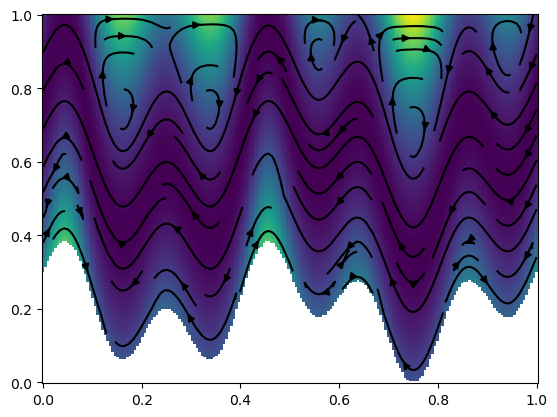

In [26]:
from jax import grad, jit, vmap
import jax.numpy as np
import numpy as nnp
import matplotlib.pyplot as plt


beta = 1
alpha = 2
rho = 0.2
f = lambda x: (np.sin(2*np.pi*5*x) + np.cos(2*np.pi*2*x)+2)*0.1

phi = lambda f, y: y-f/(beta - f)
u_phi = lambda phi, df: (rho*(3*phi - 2)*phi, -2*rho*df*phi*(1 - phi)**2)
u = lambda f: lambda x, y: u_phi(phi(f(x), y), grad(f)(x))



x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)
X, Y = np.meshgrid(x, y)
mask = Y > f(X)

(U, V) = jit(vmap(vmap(u(f), (0, 0)), (0, 0)))(X, Y)
U = np.where(mask, U, np.nan)
V = np.where(mask, V, np.nan)
plt.pcolormesh(X, Y, U)
ar = lambda x: nnp.array(x)
plt.streamplot(ar(X), ar(Y), ar(U), ar(V), color='k')

